## **Ex 8** Design and implement prediction models (Linear regression, decision tree, and ANN) for health care data.

_____

## **Aim** : 
### Design and implement prediction models (Linear regression, decision tree, and ANN) for health care data.
_____

## **Procedure** : 
 

### Hands-On Lab Procedure

1. **Set Up**: Open Google Colab and create a new notebook.
2. **Import Libraries**: Import necessary libraries:
    * `pandas`, `numpy` (Data handling)
    * `matplotlib`, `seaborn` (Visualization)
    * `sklearn` (Machine Learning & Datasets)
    * `tensorflow` (Deep Learning)
3. **Load Data**: Load healthcare data such as the **Diabetes Dataset** from scikit-learn.
4. **Preprocess the Data**: Prepare the dataset for modeling:
    * Check for missing values.
    * Split the data into features and target variable.
    * Standardize the features.
5. **Implement Linear Regression**: Train and evaluate a Linear Regression model.
    * Metrics: Mean Squared Error (MSE), $R^2$ Score.
6. **Implement Decision Tree**: Train and evaluate a Decision Tree Regressor model.
    * Metrics: Mean Squared Error (MSE), $R^2$ Score.
7. **Implement Artificial Neural Network (ANN)**: Build and train an ANN using **TensorFlow**.
    * Evaluation: Mean Squared Error, $R^2$ Score, and training history visualization.
8. **Document Findings**: Record observations, insights, and any identified patterns in a report.

---
*By following these steps, students will gain hands-on experience with various prediction models, preparing them for advanced tasks in healthcare data analysis and predictive modeling.*


## Step 0 : Import the necessary Libraries

In [8]:
# # Install the spaCy library
# %pip install spacy

# # Download the English small model (en_core_web_sm)
# !python -m spacy download en_core_web_sm

# Install transformers and wordcloud
# %pip install transformers wordcloud

# # 1. Install PyTorch (The engine for the 'transformers' library)
# %pip install torch

# # 2. Download the missing spaCy English model
# !python -m spacy download en_core_web_sm




In [1]:
!pip install optree


In [2]:
%pip install --upgrade optree typing-extensions


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# FIX: Use tensorflow.keras instead of a standalone keras import
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("Libraries imported successfully!")


Libraries imported successfully!


## Step 1 : Load the Dataset ( Diabetes Dataset)
 Create Sample Medical Text Dataset

In [4]:
from sklearn.datasets import load_diabetes

# Load the dataset
diabetes = load_diabetes()

# Convert to DataFrame for easier handling
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target)

print("Healthcare data loaded. Sample features:")
X.head()
diabetes = X


Healthcare data loaded. Sample features:


## Step 2 : Preprocessing the Text 

In [5]:
# 1. Check for missing values
print("Missing values count:\n", X.isnull().sum())

# 2. Split the data into features (X) and target (y)
# Already done during loading

# 3. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing and standardization complete.")


Missing values count:
 age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Data preprocessing and standardization complete.


In [6]:
diabetes.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

## Step 3 : Implement Linear Regression

In [7]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_lr = lr_model.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Results:")
print(f" - Mean Squared Error: {mse_lr:.2f}")
print(f" - R2 Score: {r2_lr:.2f}")


Linear Regression Results:
 - Mean Squared Error: 2900.19
 - R2 Score: 0.45


## Step 4 : Implement Decision Tree

In [8]:
# Initialize and train the model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test_scaled)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Results:")
print(f" - Mean Squared Error: {mse_dt:.2f}")
print(f" - R2 Score: {r2_dt:.2f}")


Decision Tree Results:
 - Mean Squared Error: 4887.00
 - R2 Score: 0.08


----
## Step 5 : Implement Artificial Neural Network (ANN)

C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
ANN Results:
 - Mean Squared Error: 2911.06
 - R2 Score: 0.45


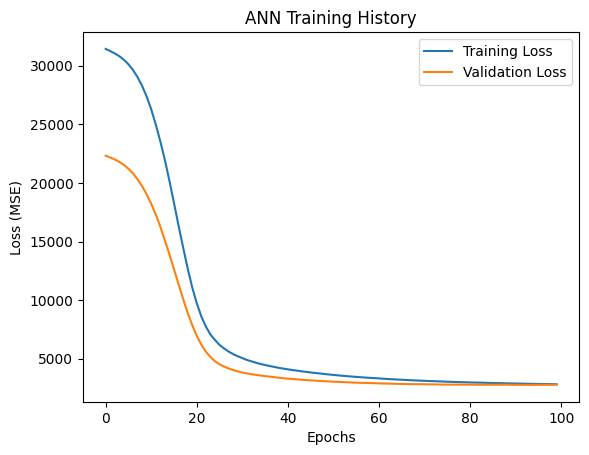

In [9]:
# Build the ANN architecture
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Final layer for regression (predicting a continuous value)
])

# Compile the model
ann_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = ann_model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2, verbose=0)

# Evaluate and visualize history
y_pred_ann = ann_model.predict(X_test_scaled).flatten()
mse_ann = mean_squared_error(y_test, y_pred_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print(f"ANN Results:")
print(f" - Mean Squared Error: {mse_ann:.2f}")
print(f" - R2 Score: {r2_ann:.2f}")

# Plotting the history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


-----
## Step 6 : Document Findings


In [10]:
# Final comparison of all models
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'ANN'],
    'MSE': [mse_lr, mse_dt, mse_ann],
    'R2 Score': [r2_lr, r2_dt, r2_ann]
})

print("Final Model Comparison Summary:")
print(comparison_df)


Final Model Comparison Summary:
               Model          MSE  R2 Score
0  Linear Regression  2900.193628  0.452603
1      Decision Tree  4887.000000  0.077603
2                ANN  2911.060309  0.450552
